# 03 · Model training (train days 1–40, tune on 41–45, calibrate/fuse on 46–50)

- **LightGBM** (Optuna-tuned, class imbalance via `scale_pos_weight`), with **XGBoost** and **logistic
  regression** as comparisons and a hand-written **rules baseline**.
- **Isolation Forest** on behaviour-deviation features (no labels).
- **Graph rules** (fan-in collector, pass-through chain, fast-flow network, reported number, shared device).
- **Fusion** weights and **0–100 score knots** fitted on the second half of validation. The test window is not read.

In [1]:
# --- setup: find the repo root (works locally, in Colab and on Kaggle) -------------------------
import os, sys, shutil, subprocess
from pathlib import Path

REPO_URL = ""          # optional: your GitHub repo URL, cloned if the code is not found
ROOT = None
for cand in [Path.cwd(), Path.cwd().parent, *Path("/kaggle/input").glob("*")] if Path("/kaggle/input").exists() else [Path.cwd(), Path.cwd().parent]:
    if (cand / "src" / "pipeline.py").exists():
        ROOT = cand
        break
if ROOT is None and REPO_URL:
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, "prohori"], check=True)
    ROOT = Path("prohori").resolve()
assert ROOT is not None, "Put this notebook next to the repo (or add the repo as a Kaggle dataset / set REPO_URL)"
if str(ROOT).startswith("/kaggle/input"):          # Kaggle inputs are read-only: work on a copy
    dst = Path("/kaggle/working/prohori")
    shutil.copytree(ROOT, dst, dirs_exist_ok=True)
    ROOT = dst
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
print("repo root:", ROOT)

repo root: H:\Tacos Projects\Hackathon\Asking for a Friend


In [2]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40, "display.width", 200)
from src.common.config import load_config, resolve
from src.models import plots
plots.style()
cfg = load_config()                 # config.yaml (seed 42, full scale)
REPORTS = resolve(cfg, "reports_dir")

In [3]:
RETRAIN = False      # True = retrain here (TRIALS below); False = load the saved bundle + report
TRIALS = 30
if RETRAIN or not (resolve(cfg, "artifacts_dir") / "model_bundle.joblib").exists():
    from src.models.train import train
    bundle, report = train(cfg, trials=TRIALS)
else:
    from src.models.scoring import load_bundle
    bundle = load_bundle(cfg)
    report = json.loads((REPORTS / "metrics_val.json").read_text(encoding="utf-8"))
print("rows:", report["split_rows"], "fraud:", report["split_fraud"])
print("LightGBM params:", report["lgbm_params"], "trees:", report["lgbm_trees"])
print("fusion weights:", report["fusion_weights"], "| score knots:", np.round(report["score_mapper"]["knots_x"], 4))

rows: {'train': 293493, 'val_fit': 32034, 'val_cal': 32189} fraud: {'train': 2153, 'val_fit': 417, 'val_cal': 360}
LightGBM params: {'learning_rate': 0.02488824083859974, 'num_leaves': 43, 'min_child_samples': 11, 'subsample': 0.954660201039391, 'colsample_bytree': 0.5552679889600102, 'reg_lambda': 0.7071771472394532, 'min_split_gain': 0.31171107608941095, 'scale_pos_weight': 12.836603951761104, 'subsample_freq': 1} trees: 777
fusion weights: {'clf': 1.0, 'anom': 0.0, 'graph': 0.0} | score knots: [0.0e+00 6.0e-04 8.6e-03 6.1e-02 1.0e+00]


## Validation comparison (val_cal, days 46–50)

In [4]:
pd.DataFrame(report["val_cal_metrics"]).set_index("model")

,pr_auc,roc_auc,recall_at_fpr_0p1,recall_at_fpr_0p5,recall_at_fpr_2,precision_at_recall_50,n,positives
model,,,,,,,,
rules_baseline,0.3113,0.9237,0.1722,0.3028,0.4891,0.2103,32189,360
paysim_isFlagged_rule,0.0112,0.5000,0.0010,0.0050,0.0200,0.0112,32189,360
logistic_regression,0.9263,0.9962,0.8639,0.9222,0.9639,0.9804,32189,360
xgboost,0.9672,0.9985,0.9417,0.9611,0.9778,1.0000,32189,360
lightgbm,0.9671,0.9988,0.9306,0.9556,0.9806,1.0000,32189,360
isolation_forest,0.4224,0.9065,0.2722,0.4028,0.5806,0.3396,32189,360
graph_rules,0.1474,0.7795,0.0579,0.2451,0.3780,0.0383,32189,360
fused_prohori,0.9671,0.9988,0.9306,0.9556,0.9806,1.0000,32189,360


In [5]:
print(json.dumps(report["val_cal_bands"], indent=1))

{
 "NUDGE+": {
  "alerts": 677,
  "tp": 348,
  "fp": 329,
  "precision": 0.514,
  "recall": 0.9667,
  "fpr": 0.01034
 },
 "STEP_UP+": {
  "alerts": 438,
  "tp": 342,
  "fp": 96,
  "precision": 0.7808,
  "recall": 0.95,
  "fpr": 0.00302
 },
 "HOLD+": {
  "alerts": 355,
  "tp": 326,
  "fp": 29,
  "precision": 0.9183,
  "recall": 0.9056,
  "fpr": 0.00091
 },
 "band_counts": {
  "ALLOW": 31512,
  "NUDGE": 239,
  "STEP_UP": 83,
  "HOLD": 355
 }
}


## Optuna search

In [6]:
p = REPORTS / "optuna_trials.csv"
if p.exists():
    t = pd.read_csv(p)
    fig, ax = plt.subplots(figsize=(7, 3.2))
    ax.plot(t.number, t.value, "o", color=plots.SERIES[0], markersize=4, label="trial")
    ax.plot(t.number, t.value.cummax(), color=plots.SERIES[1], label="best so far")
    ax.set_xlabel("Trial"); ax.set_ylabel("Val PR-AUC"); ax.set_title("Optuna: LightGBM validation PR-AUC"); ax.legend()
    plt.tight_layout(); plt.show()
    display(t.sort_values("value", ascending=False).head(5))

,number,value,learning_rate,num_leaves,min_child_samples,subsample,colsample_bytree,reg_lambda,min_split_gain,scale_pos_weight
5,5,0.993469,0.024888,43,11,0.954660,0.555268,0.707177,0.311711,12.836604
25,25,0.993194,0.020702,36,10,0.896996,0.779009,0.136131,0.592501,60.798387
14,14,0.993066,0.027370,35,10,0.924346,0.925440,1.528770,0.415980,34.716743
24,24,0.992951,0.020325,28,12,0.917125,0.891023,0.344124,0.478599,55.916294
13,13,0.992793,0.021102,29,12,0.896991,0.757235,1.785296,0.418525,14.135960


## Feature importance (gain)

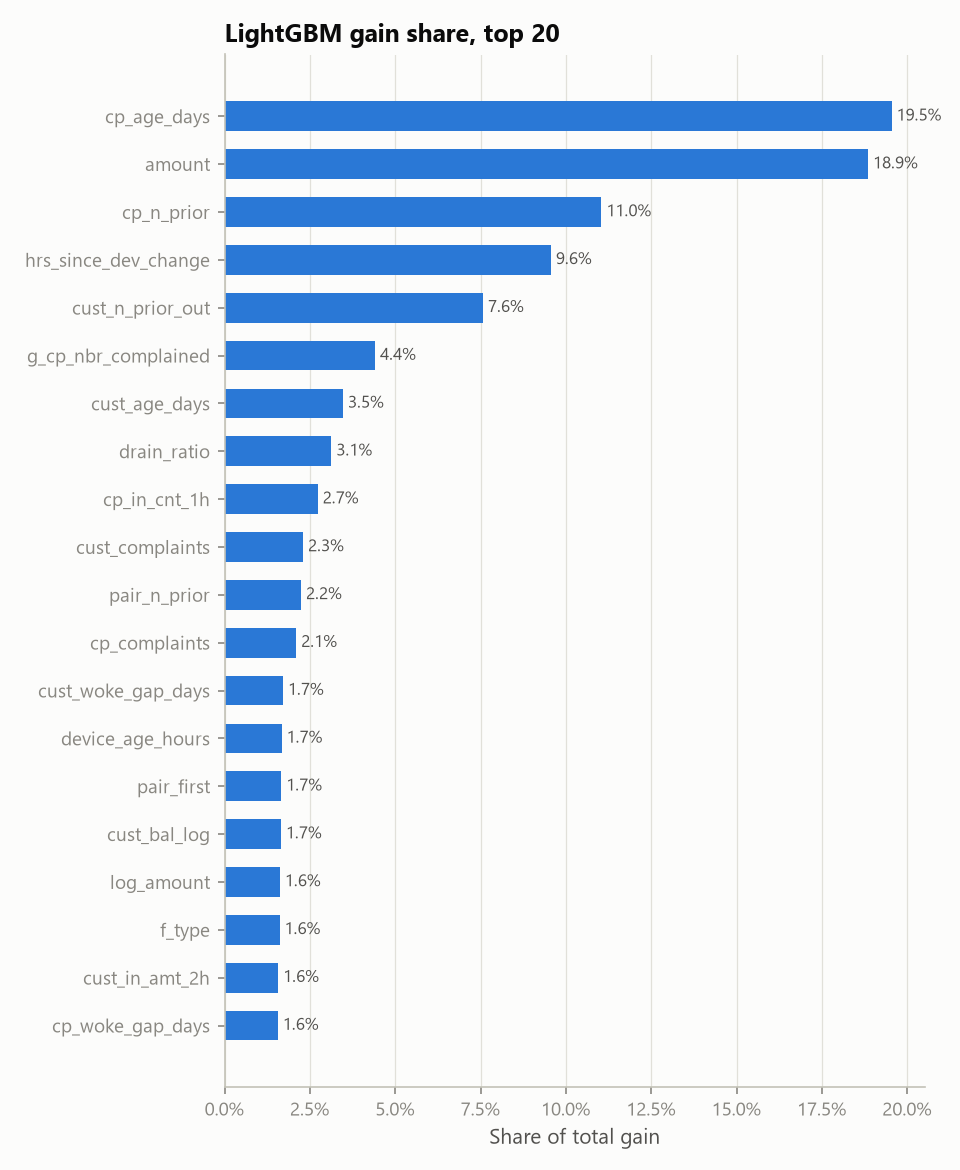

In [7]:
imp = pd.Series(report["top_features_gain"]).head(20)
plots.hbar((imp / imp.sum()).round(4).to_dict(), REPORTS / "figures" / "lgbm_gain_top20.png", "LightGBM gain share, top 20", "Share of total gain", fmt="{:.1%}")
display(Image(filename=str(REPORTS / "figures" / "lgbm_gain_top20.png")))